
<h2 style="color:#FF5733">Reading Data</h2>

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
data= pd.read_csv("Zara_sales_EDA.csv", sep =";")
df = pd.DataFrame(data)

<h2 style="color:#FF5733">Expoling Data</h2>


In [ ]:
print(df.info())

In [ ]:
print(df.duplicated().sum())

In [ ]:
print(df['Promotion'].unique())

In [ ]:
print(df['Seasonal'].unique())

<h2 style="color:#FF5733">Cleaning Data </h2>


In [ ]:
df["name"] = df["name"].fillna("Missing")
df["description"]= df["description"].fillna("Missing")
df = df.drop(columns=['url'])


<h2 style="color:#FF5733">Univariate Analysis & visualization</h2>


# 1-Price

In [ ]:
print( df["price"].describe())

In [ ]:
sns.histplot(data = df["price"],bins=10,kde=True,color="green")
plt.title("Price Distribution")
plt.show()
# The majority of products are priced between 20 and 40, indicating that Zara mainly focuses on mid-range price
# There are a small number of products with higher prices, reaching up to 134
# The distribution is skewed towards mid-range prices

In [ ]:
sns.boxplot(data = df["price"],color="green")
sns.set_style("darkgrid")
plt.title("Price Distribution")
plt.show()
# The boxplot shows that most product prices are concentrated between 24 and 54, with a median around 36. 
# There are a few higher-priced outliers, indicating the presence of premium products 


# 2- Sales Volume

In [ ]:
print(df["Sales Volume"].describe())

In [ ]:
sns.histplot(data = df["Sales Volume"],bins=20,kde=True,color="red")
plt.title("Sales Volume Distribution")
plt.show()
#Most products sell between 800 and 1400 units. A few products sell much more, which shows the top-performing items

In [ ]:
sns.boxplot(data = df["Sales Volume"],color="red")
sns.set_style("darkgrid")
plt.title(" Sales Volume Distribution")
plt.show()
# Most products sell between 849 and 1364 units, with a median of 990. A few products sell much more, indicating top-performing items

# 3- Product Category

In [ ]:
print(df["Product Category"].value_counts())
# All products in the dataset belong to the "clothing" category
# indicating that Zara's dataset focuses exclusively on apparel. No other product categories are represented.

# 4- Promotion

In [ ]:
print(df["Promotion"].value_counts())

In [ ]:
promo_counts = df["Promotion"].value_counts().reset_index()
promo_counts.columns = ["Promotion", "Count"]
sns.barplot(data=promo_counts,x="Promotion",y="Count",width=0.4,color="purple")
plt.title("Promotion Distribution")
plt.show()
# Most products are not under promotion, indicating that Zara’s catalog is largely sold at regular prices.
# Only a small portion of products is offered under promotional campaigns

# 5- Seasonal

In [ ]:
print(df["Seasonal"].value_counts())

In [ ]:
promo_counts = df["Seasonal"].value_counts().reset_index()
promo_counts.columns = ["Seasonal", "Count"]
sns.barplot(data=promo_counts,x="Seasonal",width=0.4,y="Count",color="skyblue")
plt.title("Seasonal Distribution")
plt.show()
# The dataset shows a nearly equal distribution between seasonal and non-seasonal products, with 10,116 seasonal items and 10,136 non-seasonal items.
#  This indicates Zara maintains a balanced catalog, offering both year-round and season-specific products.

# 6- Season

In [ ]:
print(df["season"].value_counts())

In [ ]:
season_count=df["season"].value_counts().reset_index()
season_count.columns=["season","count"]
sns.barplot(data=season_count,x="season",y="count",color="pink")
plt.title("Season Distribution")
plt.show()
# The distribution of products by season shows that most items are designed for Autumn (7,665) and Winter (5,144), indicating a stronger focus on cooler seasons.
#  Spring (4,537) and Summer (2,906) products are fewer, reflecting seasonal inventory planning and market demand.

# 7- Section

In [ ]:
print(df["section"].value_counts())

In [ ]:
section_count=df["section"].value_counts().reset_index()
section_count.columns=["section","count"]
sns.barplot(data=section_count,x="section",y="count",width=0.4,color="brown")
plt.title("Section Distribution")
plt.show()
# Most products are for Women, and Men sections having fewer items, showing Zara’s main focus on the Women category.

# 8- Material

In [ ]:
print(df["material"].value_counts())

In [ ]:
material_count=df["material"].value_counts().reset_index()
material_count.columns=["material","count"]
plt.figure(figsize=(10,6))
sns.barplot(data=material_count,x="material",y="count",width=0.4,color="blue")
plt.title("Material Distribution")
plt.show()
# The product distribution by material shows that Cotton, Wool, and Wool Blend dominate the catalog, reflecting Zara’s focus on popular everyday fabrics.
#  Polyester and Linen are also significant, while premium fabrics like Satin and Silk are rare, likely reserved for special items.

# 9- Origin

In [ ]:
print(df["origin"].value_counts())

In [ ]:
origin_count=df["origin"].value_counts().reset_index()
origin_count.columns=["origin","count"]
plt.figure(figsize=(10,6))
sns.barplot(data=origin_count,x="origin",y="count",width=0.4,color="gray")
plt.title("origin Distribution")
plt.show()
# Most products are manufactured in China, Bangladesh, Turkey, and India, indicating Zara’s reliance on large-scale production in Asia. 
# European countries like Portugal and Spain contribute a smaller portion, 
# likely representing premium or specialized items, while South American origins like Brazil and Argentina are minimal.

<h2 style="color:#FF5733">Bivariate , Multivariate Analysis & visualization</h2>


<h2 style = "color:green"> 1- Price vs Sales volume</h2>

In [ ]:
print(df[["price","Sales Volume"]].corr())
# There is a weak negative correlation between price & sales volume

In [ ]:
plt.figure(figsize=(8,5))
plt.hexbin(df["price"],df["Sales Volume"],gridsize=50,cmap="Reds")
plt.title("Relation between price & Sales Volume ")
plt.xlabel("Price")
plt.ylabel('Sales Volume')
plt.show()


<h2 style = "color:green"> 2- Promotion vs Sales volume</h2>

In [ ]:
print("\n------")
print("Mean")
print("------")
print(df.groupby("Promotion")['Sales Volume'].mean())
print("\n------")
print("Median")
print("------")
print(df.groupby("Promotion")['Sales Volume'].median())
print("\n------")
print("Max")
print("------")
print(df.groupby("Promotion")['Sales Volume'].max())



In [ ]:
sns.barplot(data=df,x="Promotion",y="Sales Volume",width=0.4,color="purple")
plt.title("Promotion vs Sales Volume")
plt.show()

In [ ]:
sns.boxenplot(data=df,x="Promotion",y="Sales Volume",color="purple")
plt.title("Promotion vs Sales Volume")
plt.show()

<h2 style = "color:green"> 3- Section vs Sales volume</h2>

In [ ]:
print("\n------")
print("Mean")
print("------")
print(df.groupby("section")['Sales Volume'].mean())
print("\n------")
print("Median")
print("------")
print(df.groupby("section")['Sales Volume'].median())
print("\n------")
print("Max")
print("------")
print(df.groupby("section")['Sales Volume'].max())



In [ ]:
sns.boxplot(data=df,x="section",y="Sales Volume",color="brown")
plt.title("Section vs Sales Volume")
plt.show()

In [ ]:
sns.barplot(data=df,x="section",y="Sales Volume",width=0.4,color="brown")
plt.title("Section vs Sales Volume")
plt.show()

<h2 style = "color:green"> 3- Seasonal vs Sales volume</h2>

In [ ]:
print("\n------")
print("Mean")
print("------")
print(df.groupby("Seasonal")['Sales Volume'].mean())
print("\n------")
print("Median")
print("------")
print(df.groupby("Seasonal")['Sales Volume'].median())
print("\n------")
print("Max")
print("------")
print(df.groupby("Seasonal")['Sales Volume'].max())



In [ ]:
sns.boxplot(data=df,x="Seasonal",y="Sales Volume",color="skyblue")
plt.title("Seasonal vs Sales Volume")
plt.show()

In [ ]:
sns.barplot(data=df,x="Seasonal",y="Sales Volume",width=0.4,color="skyblue")
plt.title("Seasonal vs Sales Volume")
plt.show()

<h2 style = "color:green"> 4- Season vs Sales volume</h2>

In [ ]:
print("\n------")
print("Mean")
print("------")
print(df.groupby("season")['Sales Volume'].mean())
print("\n------")
print("Median")
print("------")
print(df.groupby("season")['Sales Volume'].median())
print("\n------")
print("Max")
print("------")
print(df.groupby("season")['Sales Volume'].max())



In [ ]:
sns.violinplot(data=df,x="season",y="Sales Volume",color="pink")
plt.title("Season vs Sales Volume")
plt.show()

In [ ]:
sns.barplot(data=df,x="season",y="Sales Volume",width=0.4,color="pink")
plt.title("season vs Sales Volume")
plt.show()

<h2 style = "color:green"> 5- Material vs Sales volume</h2>

In [53]:
print("\n------")
print("Mean")
print("------")
print(df.groupby("material")['Sales Volume'].mean())



------
Mean
------
material
Acrylic        1119.257662
Cotton         1091.226175
Denim          1070.890944
Linen          1104.127478
Linen Blend    1125.240397
Polyester      1078.218018
Satin          1078.666667
Silk           1066.473684
Viscose        1085.854545
Wool           1105.521156
Wool Blend     1106.111177
Name: Sales Volume, dtype: float64


In [54]:
print("\n------")
print("Median")
print("------")
print(df.groupby("material")['Sales Volume'].median())


------
Median
------
material
Acrylic        1024.0
Cotton          986.0
Denim           947.0
Linen           998.0
Linen Blend    1021.0
Polyester       968.0
Satin           956.5
Silk            906.5
Viscose         978.5
Wool            992.0
Wool Blend     1004.0
Name: Sales Volume, dtype: float64


In [55]:
print("\n------")
print("Max")
print("------")
print(df.groupby("material")['Sales Volume'].max())


------
Max
------
material
Acrylic        1864
Cotton         1940
Denim          1908
Linen          1926
Linen Blend    1839
Polyester      1940
Satin          1767
Silk           1699
Viscose        1848
Wool           1929
Wool Blend     1917
Name: Sales Volume, dtype: int64


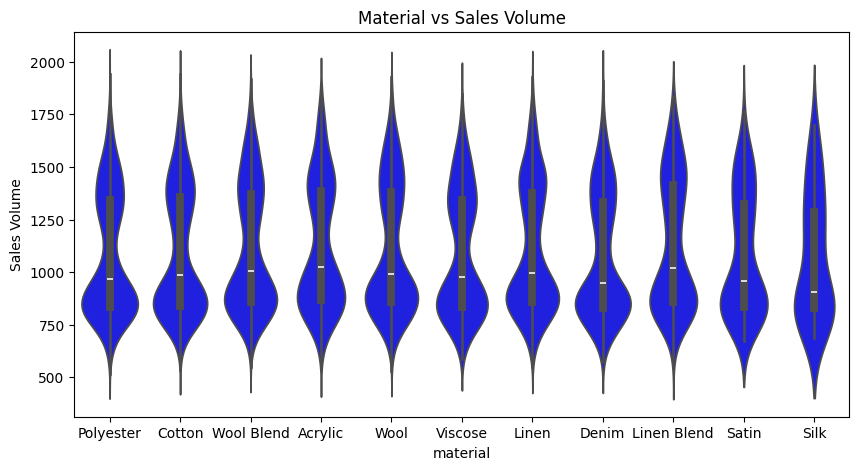

In [59]:
plt.figure(figsize=(10,5))
sns.violinplot(data=df,x="material",y="Sales Volume",color="blue")
plt.title("Material vs Sales Volume")
plt.show()

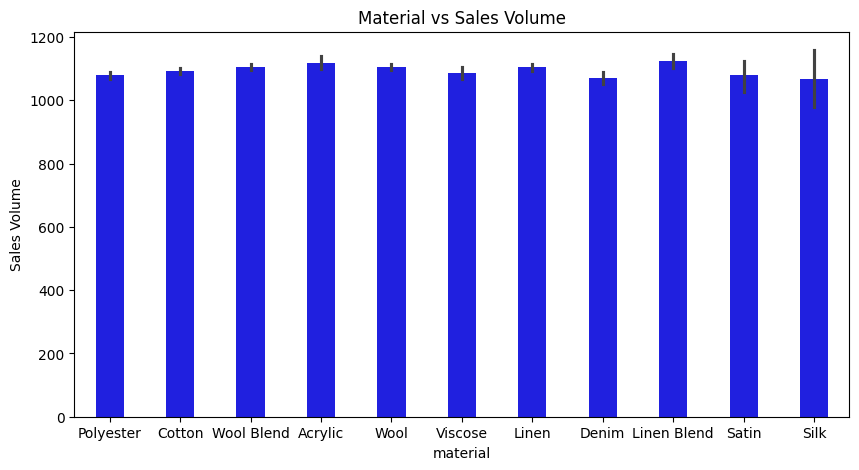

In [61]:
plt.figure(figsize=(10,5))
sns.barplot(data=df,x="material",y="Sales Volume",width=0.4,color="blue")
plt.title("Material vs Sales Volume")
plt.show()